## Tasmanian Conditioning
This notebook exists to process hand-scored data from CCNL planarian conditioning projects that follow the protocls described in [James et al. (2025)](https://drive.google.com/file/d/1QFx8QHdXEkjAiJImBWZC_EdjRTzK_7hg/view?usp=drive_link). The data can be found [here](https://docs.google.com/spreadsheets/d/1M-xnRcIi3IS6-G30y5ylytBrqeMi3pINym3OKOTZn3c/edit?usp=sharing). This notebook is geared for reporting sums on a day.

I'm visually comparing my data to Sage's. It'll be plotting essentially the same structure of lines on a graph, color coded depending on whether they came from Sage or my data (manually scored turns and contractions per video).

## Import packages, set filepaths, configure styles.

In [6]:
# ==============================================================================
# BLOCK 1: INITIALIZATION, CONFIGURATION, AND DATA LOADING
# ==============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from scipy import stats

# Define save path
SAVE_PATH = "../figures"

# SCORER CONFIGURATION DICTIONARY
# Flat keys for TC/TP and Turn/Contraction combinations
# Added *_dodge parameters for manual mean dodging (X-axis offset)
SCORER_CONFIG = {  
    'Zach_Everything_Blind': {
        'csv_path': "../hand_scored_datasheets/Zach_Tasmdata_Tidy_All_Blind_Compiled.csv",
        'enabled': True,            
        'label_name': 'G. dorotocephala',       
        'tc_turn_color': '#1f4788ff', 'tc_turn_linestyle': '-',  'tc_turn_marker': 'o', 'tc_turn_dodge': 0,
        'tc_con_color': '#1f4788ff',  'tc_con_linestyle': '--',  'tc_con_marker': '^',  'tc_con_dodge': 0,
        'tp_turn_color': '#9e9e9eff', 'tp_turn_linestyle': '-',  'tp_turn_marker': 'o', 'tp_turn_dodge': -0.05,
        'tp_con_color': '#9e9e9eff',  'tp_con_linestyle': '--',  'tp_con_marker': '^',  'tp_con_dodge': 0.05,
        'markersize': 8, 'linewidth': 3, 'alpha': 1.0
    },
    'Zach_GD-2_blind': {
        'csv_path': "../hand_scored_datasheets/Zach_Tasmdata_Tidy_GD-2_blind.csv",
        'enabled': True,            
        'label_name': 'G. dor (Carolina)',       
        'tc_turn_color': '#1f4788ff', 'tc_turn_linestyle': '-',  'tc_turn_marker': 'o', 'tc_turn_dodge': 0,
        'tc_con_color': '#1f4788ff',  'tc_con_linestyle': '--',  'tc_con_marker': '^',  'tc_con_dodge': 0,
        'tp_turn_color': '#9e9e9eff', 'tp_turn_linestyle': '-',  'tp_turn_marker': 'o', 'tp_turn_dodge': -0.05,
        'tp_con_color': '#9e9e9eff',  'tp_con_linestyle': '--',  'tp_con_marker': '^',  'tp_con_dodge': 0.05,
        'markersize': 8, 'linewidth': 3, 'alpha': 1.0
    },
    'Zach_SM_blind': {
        'csv_path': "../hand_scored_datasheets/Zach_Tasmdata_Tidy_SM_blind.csv",
        'enabled': True,            
        'label_name': 'S. mediterranea',       
        'tc_turn_color': '#b09724', 'tc_turn_linestyle': '-',  'tc_turn_marker': 'o', 'tc_turn_dodge': -0.1,
        'tc_con_color': '#b09724',  'tc_con_linestyle': '--',  'tc_con_marker': '^',  'tc_con_dodge': -0.1,
        'tp_turn_color': '#9e9e9eff', 'tp_turn_linestyle': '--','tp_turn_marker': 'o', 'tp_turn_dodge': 0,
        'tp_con_color': '#9e9e9eff',  'tp_con_linestyle': '--', 'tp_con_marker': 's',  'tp_con_dodge': 0,
        'markersize': 8, 'linewidth': 3, 'alpha': 1.0
    },
    'Zach_GD-MI_blind': {
        'csv_path': "../hand_scored_datasheets/Zach_Tasmdata_Tidy_GD-MI_blind.csv",
        'enabled': True,            
        'label_name': 'G. dor. (Michigan)',       
        'tc_turn_color': '#197678', 'tc_turn_linestyle': '-',  'tc_turn_marker': 'o', 'tc_turn_dodge': -0.15,
        'tc_con_color': '#197678',  'tc_con_linestyle': '--',  'tc_con_marker': '^',  'tc_con_dodge': -0.15,
        'tp_turn_color': '#9e9e9eff', 'tp_turn_linestyle': '--','tp_turn_marker': 'o', 'tp_turn_dodge': -0.1,
        'tp_con_color': '#9e9e9eff',  'tp_con_linestyle': '--', 'tp_con_marker': 's',  'tp_con_dodge': -0.1,
        'markersize': 8, 'linewidth': 3, 'alpha': 1.0
    }
}

# Load dataframes from csv for each scorer that is enabled
dfs = {}
for scorer, config in SCORER_CONFIG.items():
    if config['enabled']:
        try:
            dfs[scorer] = pd.read_csv(config['csv_path'])
            print(f"Loaded data for Scorer")
        except FileNotFoundError:
            print(f"Warning: Could not find CSV for Scorer at {config['csv_path']}")
        except Exception as e:
            print(f"Error loading Scorer: {e}")

# Report unique runs and troupes
print("\n" + "="*60)
print("DATA SUMMARY")
print("="*60)

for scorer in dfs.keys():
    print(f"Scorer's data:")
    df = dfs[scorer]
    unique_runs = df['Run'].nunique()
    unique_troupes = df['Troupe'].nunique()
    print(f"\tUnique troupes: {sorted(df['Troupe'].unique())}")
    print(f"\tNumber of unique runs: {unique_runs}")
    print(f"\tNumber of unique troupes: {unique_troupes}")
    print(f"\tTroupes and runs agree? {unique_runs / unique_troupes == 8}.")

print("="*60 + "\n")

Loaded data for Scorer
Loaded data for Scorer
Loaded data for Scorer
Loaded data for Scorer

DATA SUMMARY
Scorer's data:
	Unique troupes: ['TC-1', 'TC-2', 'TC-3', 'TC-4', 'TC-5', 'TC-6', 'TC-7', 'TC-MI-1', 'TP-1', 'TP-2', 'TP-3', 'TP-4']
	Number of unique runs: 96
	Number of unique troupes: 12
	Troupes and runs agree? True.
Scorer's data:
	Unique troupes: ['TC-1', 'TC-2', 'TC-3', 'TC-4', 'TC-5', 'TC-6', 'TC-7', 'TC-MI-1', 'TP-1', 'TP-2', 'TP-3', 'TP-4']
	Number of unique runs: 96
	Number of unique troupes: 12
	Troupes and runs agree? True.
Scorer's data:
	Unique troupes: ['TC-1', 'TC-2', 'TC-3', 'TC-4', 'TC-5', 'TC-6', 'TC-7', 'TC-MI-1', 'TP-1', 'TP-2', 'TP-3', 'TP-4']
	Number of unique runs: 96
	Number of unique troupes: 12
	Troupes and runs agree? True.
Scorer's data:
	Unique troupes: ['TC-1', 'TC-2', 'TC-3', 'TC-4', 'TC-5', 'TC-6', 'TC-7', 'TC-MI-1', 'TP-1', 'TP-2', 'TP-3', 'TP-4']
	Number of unique runs: 96
	Number of unique troupes: 12
	Troupes and runs agree? True.



## Define CSV analysis and graphing functions

In [7]:
# ==============================================================================
# BLOCK 2: FUNCTIONS (ANALYSIS, TABLES, GRAPHING)
# ==============================================================================

def _bootstrap_ci_mean(values, n_boot=10000, ci=0.95, seed=0):
    """Percentile bootstrap CI for the mean of `values`.

    Returns (mean, lo, hi) where (lo, hi) is the symmetric percentile
    CI on the sample mean. Distribution-free; preferred for small /
    skewed samples where SEM-based intervals are mis-calibrated.
    """
    arr = np.asarray(values, dtype=float)
    arr = arr[np.isfinite(arr)]
    n = arr.size
    if n == 0:
        return (np.nan, np.nan, np.nan)
    m = float(arr.mean())
    if n < 2:
        return (m, m, m)
    rng = np.random.default_rng(seed)
    idx = rng.integers(0, n, size=(n_boot, n))
    boot_means = arr[idx].mean(axis=1)
    alpha = (1.0 - ci) / 2.0
    lo, hi = np.quantile(boot_means, [alpha, 1.0 - alpha])
    return (m, float(lo), float(hi))


def analyze_raw_counts(df, troupes=None, days=None, verbose=True):
    behavioral_columns = [f"{behavior}_W{worm}" for behavior in ['CRturn', 'CRcon', 'UCRturn', 'UCRcon'] for worm in range(1, 7)]
    df_numeric = df.copy()
    for col in behavioral_columns:
        if col in df_numeric.columns:
            df_numeric[col] = pd.to_numeric(df_numeric[col], errors='coerce').fillna(0)
            
    if troupes is None: troupes = df_numeric['Troupe'].unique()
    if days is None: days = df_numeric['Day'].unique()
    
    filtered_df = df_numeric[df_numeric['Troupe'].isin(troupes) & df_numeric['Day'].isin(days)].copy()
    results = []
    
    for troupe in troupes:
        for day in days:
            subset = filtered_df[(filtered_df['Troupe'] == troupe) & (filtered_df['Day'] == day)]
            if len(subset) == 0: continue
            for worm_num in range(1, 7):
                worm_id = f"W{worm_num}"
                crturn_sum = subset[f'CRturn_{worm_id}'].sum()
                crcon_sum = subset[f'CRcon_{worm_id}'].sum()
                ucrturn_sum = subset[f'UCRturn_{worm_id}'].sum()
                ucrcon_sum = subset[f'UCRcon_{worm_id}'].sum()
                
                results.append({
                    'Troupe': troupe, 'Worm': worm_id, 'Day': day,
                    'CRturn': crturn_sum, 'CRcon': crcon_sum,
                    'UCRturn': ucrturn_sum, 'UCRcon': ucrcon_sum,
                    'UCRcombined': ucrcon_sum + ucrturn_sum,
                    'CRcombined': crcon_sum + crturn_sum
                })
                
    summary_df = pd.DataFrame(results)
    if len(summary_df) > 0:
        summary_df['Worm_sort'] = summary_df['Worm'].str.extract('(\d+)').astype(int)
        summary_df = summary_df.sort_values(['Troupe', 'Worm_sort', 'Day']).reset_index(drop=True)
        summary_df = summary_df.drop('Worm_sort', axis=1)
    return summary_df


def create_behavior_summary_table(scorer, tc_troupes=None, tp_troupes=None, behaviors=['CRturn'], days=[1, 4], error_type='SEM'):
    if scorer not in dfs: raise ValueError(f"Scorer '{scorer}' not found.")
    df = dfs[scorer]
    behavior_list = [behaviors] if isinstance(behaviors, str) else behaviors
    results = []
    
    for group_name, troupes in [('TC', tc_troupes), ('TP', tp_troupes)]:
        if troupes is None: continue
        troupes = [troupes] if isinstance(troupes, str) else troupes
        filtered_df = df[df['Troupe'].isin(troupes) & df['Day'].isin(days)].copy()
        
        if not filtered_df.empty:
            for behavior in behavior_list:
                behavioral_columns = [f"{behavior}_W{worm}" for worm in range(1, 7)]
                for col in behavioral_columns:
                    if col in filtered_df.columns:
                        filtered_df[col] = pd.to_numeric(filtered_df[col], errors='coerce')
                
                for day in sorted(days):
                    day_data = filtered_df[filtered_df['Day'] == day]
                    if day_data.empty: continue
                    
                    all_values = []
                    for col in behavioral_columns:
                        if col in day_data.columns:
                            all_values.extend(day_data[col].dropna().tolist())
                    
                    if all_values:
                        mean_val = np.mean(all_values)
                        sem_val = np.std(all_values, ddof=1) / np.sqrt(len(all_values))
                        error_val = stats.t.ppf(0.975, df=len(all_values)-1) * sem_val if error_type.upper() in ['95CI', 'CI'] else sem_val
                        error_label = '95% CI' if error_type.upper() in ['95CI', 'CI'] else 'SEM_Error'
                        
                        results.append({
                            'Scorer': scorer, 'Group': group_name, 'Behavior': behavior, 'Day': day,
                            'Mean': round(mean_val, 2), 'SEM': round(sem_val, 3),
                            f'{error_label}': round(error_val, 3), 'N': len(all_values),
                            'Std': round(np.std(all_values, ddof=1), 2)
                        })
                        
    summary_df = pd.DataFrame(results)
    if not summary_df.empty:
        summary_df = summary_df.sort_values(['Behavior', 'Group', 'Day']).reset_index(drop=True)
    return summary_df


def _count_individuals(df, troupes, behaviors, days):
    """Number of distinct worm individuals (Troupe × W#) with at least one
    non-NaN score across the given behaviors and days."""
    seen = set()
    sub = df[df['Troupe'].isin(troupes) & df['Day'].isin(days)]
    if sub.empty:
        return 0
    for behavior in behaviors:
        for w in range(1, 7):
            col = f"{behavior}_W{w}"
            if col not in sub.columns:
                continue
            vals = pd.to_numeric(sub[col], errors='coerce')
            mask = vals.notna()
            if not mask.any():
                continue
            for troupe in sub.loc[mask, 'Troupe'].unique():
                seen.add((troupe, w))
    return len(seen)


def create_day_comparison_lines(tc_troupes, tp_troupes, scorers=None, behaviors=['CRturn', 'CRcon'], 
                                days=[1, 4], figsize=(8, 6), SAVE=False, filename="", ylim=6.0, 
                                marker_size=None, line_width=None, show_legend=True, 
                                simplify_legend=True, error_type='BOOTSTRAP'):
    """
    Plots ALL specified behaviors and scorers onto a SINGLE graph.
    simplify_legend: If True, legends only show CC/PC rather than repeating for turns/contractions.

    Each legend label is suffixed with `(n=N)` where N is the number of
    distinct worm individuals (Troupe × W#) contributing at least one
    non-NaN score to that line.

    error_type:
        'BOOTSTRAP' (default) - 95% percentile bootstrap CI on the daily mean
                                (10 000 resamples, distribution-free, asymmetric).
                                Recommended for the skewed / non-normal per-trial
                                per-worm count distributions seen here.
        '95CI' / 'CI'         - symmetric t-based 95% CI ( = t_{0.975, n-1} x SEM ).
        'SEM'                 - +/- 1 standard error of the mean.
    """
    if scorers is None: scorers = list(dfs.keys())
    elif isinstance(scorers, str): scorers = [scorers]
    behavior_list = [behaviors] if isinstance(behaviors, str) else behaviors

    fig, ax = plt.subplots(figsize=figsize)  # Title here
    fig.suptitle('', fontsize=16, fontweight='bold')

    # Track what has been added to legend to keep it clean if simplify_legend is True
    added_to_legend = set()

    for scorer in scorers:
        df = dfs[scorer]
        config = SCORER_CONFIG[scorer]
        
        current_marker_size = marker_size if marker_size is not None else config['markersize']
        current_line_width = line_width if line_width is not None else config['linewidth']
        
        for current_behavior in behavior_list:
            is_turn = 'turn' in current_behavior.lower()
            beh_type = 'turn' if is_turn else 'con'

            for troupe_group, troupe_list in [('TC', tc_troupes), ('TP', tp_troupes)]:
                group = troupe_group.lower() # 'tc' or 'tp'
                
                # Fetch specific dictionary keys based on behavior and group
                color = config[f'{group}_{beh_type}_color']
                linestyle = config[f'{group}_{beh_type}_linestyle']
                marker = config[f'{group}_{beh_type}_marker']
                dodge = config.get(f'{group}_{beh_type}_dodge', 0.0) # <--- GET DODGE OFFSET

                filtered_df = df[df['Troupe'].isin(troupe_list) & df['Day'].isin(days)].copy()
                if filtered_df.empty: continue
                
                behavioral_columns = [f"{current_behavior}_W{worm}" for worm in range(1, 7)]
                for col in behavioral_columns:
                    if col in filtered_df.columns:
                        filtered_df[col] = pd.to_numeric(filtered_df[col], errors='coerce')

                plot_days, plot_means = [], []
                plot_err_lo, plot_err_hi = [], []   # distances below/above the mean
                for day in sorted(days):
                    day_data = filtered_df[filtered_df['Day'] == day]
                    if day_data.empty: continue
                    
                    all_day_values = []
                    for col in behavioral_columns:
                        if col in day_data.columns:
                            all_day_values.extend(day_data[col].dropna().tolist())
                    
                    if all_day_values:
                        n_obs    = len(all_day_values)
                        day_mean = float(np.mean(all_day_values))
                        et       = str(error_type).upper()
                        if et == 'BOOTSTRAP' and n_obs >= 2:
                            _, lo, hi = _bootstrap_ci_mean(all_day_values)
                            err_lo = day_mean - lo
                            err_hi = hi - day_mean
                        elif et in ('95CI', 'CI') and n_obs >= 2:
                            sem = np.std(all_day_values, ddof=1) / np.sqrt(n_obs)
                            half = stats.t.ppf(0.975, df=n_obs - 1) * sem
                            err_lo, err_hi = half, half
                        else:   # 'SEM' (or n<2 fallback)
                            sem = (np.std(all_day_values, ddof=1) / np.sqrt(n_obs)
                                   if n_obs >= 2 else 0.0)
                            err_lo, err_hi = sem, sem
                        
                        plot_days.append(day)
                        plot_means.append(day_mean)
                        plot_err_lo.append(err_lo)
                        plot_err_hi.append(err_hi)

                if plot_days:
                    # Apply the manual dodge to the X coordinates
                    plot_days_dodged = [d + dodge for d in plot_days]
                    
                    # Legend logic
                    display_group = "CC" if troupe_group == 'TC' else "PC"

                    # Count distinct worm individuals contributing to this line.
                    # In simplify_legend mode one legend entry stands in for both
                    # Turn and Con behaviours, so we count across all behaviours
                    # in behavior_list. Otherwise we count for the specific
                    # behaviour being plotted.
                    behaviours_for_count = (
                        behavior_list if simplify_legend else [current_behavior]
                    )
                    n_individuals = _count_individuals(
                        df, troupe_list, behaviours_for_count, days
                    )

                    if simplify_legend:
                        legend_key = f"{scorer}_{display_group}"
                        if legend_key not in added_to_legend and is_turn: # Only add Turn lines to proxy the group
                            label = f"{config['label_name']} {display_group} (n={n_individuals})"
                            added_to_legend.add(legend_key)
                        else:
                            label = "_nolegend_"
                    else:
                        label = (
                            f"{config['label_name']} {display_group} "
                            f"{current_behavior} (n={n_individuals})"
                        )

                    # Plot using the dodged X coordinates.  yerr is passed as
                    # [lower_distances, upper_distances] so it supports both
                    # symmetric (SEM, 95% t-CI) and asymmetric (bootstrap CI) bars.
                    ax.errorbar(plot_days_dodged, plot_means, yerr=[plot_err_lo, plot_err_hi],
                                color=color, linestyle=linestyle, linewidth=current_line_width,
                                marker=marker, markersize=current_marker_size, capsize=5,
                                alpha=config['alpha'], label=label)

    # Formatting the single axis
    behaviors_str = " & ".join(behavior_list)
    ax.set_ylabel(f'Behavior Score', fontsize=11, fontweight='bold')
    ax.set_xlabel('Day', fontsize=11, fontweight='bold')
    ax.set_title(f'', fontsize=12)

    ax.set_ylim(0, ylim if ylim is not None else 6.0)
    ax.set_xticks(days) # Keeps the bottom axis labels firmly pinned on the integers
    ax.set_xticklabels([f'Day {d}' for d in days])
    ax.grid(True, which='major', axis='y', linestyle='--', alpha=0.3)
    
    if show_legend:
        ax.legend(loc='best', framealpha=0.9, fontsize=9)
        
    plt.tight_layout()
    
    if SAVE:
        if not filename:
            b_str = "_".join(behavior_list)
            d_str = "_".join(map(str, sorted(days)))
            s_str = "_".join(scorers)
            filename = f"Combined_Comparison_{s_str}_{b_str}_days{d_str}.svg"
        
        filepath = os.path.join(SAVE_PATH, filename)
        fig.savefig(filepath, dpi=300, bbox_inches='tight')
        print(f"Plot saved to: {filepath}")
        plt.close(fig)
    else:
        plt.show()

## Call and execute graphing functions.

In [8]:
# ==============================================================================
# BLOCK 3: EXECUTE GRAPHING AND SUMMARY TABLES
# ==============================================================================

# 1. Create the combined graph 
# NOTE: simplify_legend=True makes the legend only report "CC" and "PC" to keep it clean.
create_day_comparison_lines(
    tc_troupes=['TC-6', 'TC-7', 'TC-2', 'TC-3', 'TC-4', 'TC-5', 'TC-MI-1'],
    tp_troupes=['TP-3', 'TP-4'],
    scorers=['Zach_SM_blind', 'Zach_GD-MI_blind', 'Zach_GD-2_blind'],    # Just Zach for now -- this was a mix of blind and unblind

    behaviors=['CRturn', 'CRcon'],                # Putting both on the same graph
    days=[1, 2, 3, 4],
    figsize=(8, 6),
    ylim=6.0,                                     # Shared Y-axis limit
    error_type='BOOTSTRAP',                       # 95% percentile bootstrap CI on the daily mean
                                                  #  (distribution-free; matches Fig 2A/2B convention
                                                  #   for skewed per-trial-per-worm counts)
    simplify_legend=True,                         # Set to False if you want Turn/Con labeled individually
    SAVE=True,
    filename='Fig_S1A_Blind_SpeciesSplit.svg'
)

print("Combined plot generated successfully.\n")

# 2. Generate Behavior Summary Table
combined_summaries = []
for scorer_name in ['Zach_GD-2_blind']:
    summary = create_behavior_summary_table(
        scorer=scorer_name,
        tc_troupes=['TC-6', 'TC-7'],
        tp_troupes=['TP-3', 'TP-4'],
        behaviors=['CRturn', 'CRcon'],
        days=[1, 2, 3, 4],
        error_type='95CI'
    )
    combined_summaries.append(summary)

# Combine all scorer summaries into one dataframe
if combined_summaries:
    all_scorers_summary = pd.concat(combined_summaries, ignore_index=True)

Plot saved to: ../figures/Fig_S1A_Blind_SpeciesSplit.svg
Combined plot generated successfully.



## Compare per-population slopes to Jacobson (1966) CC reference

For every (species × group × behaviour) population shown in the figure above
we compute per-worm OLS slopes of the **daily summed behaviour count** vs
**Day**, then compare the resulting slope distribution to Jacobson's published
CC slope using:

1. **One-sample t-test** — Jacobson treated as a fixed reference.
2. **Welch's t-test** — accounts for the SE of Jacobson's regression.

Slope distributions across worms are approximately normal by the CLT
(linear combinations of bounded counts), so t-based inference is appropriate
here even though the *raw* per-worm-per-block counts are not normal
(see Fig 2 normality check). A forest plot at the bottom shows every
population's mean slope ± 95% CI alongside Jacobson's reference.

In [9]:
# ==============================================================================
# BLOCK 4: SLOPE COMPARISON vs JACOBSON (1966) CC REFERENCE
# ==============================================================================
# Per-worm OLS slopes of (CRturn or CRcon) daily totals vs Day, then the slope
# distribution is compared to Jacobson's CC slope using:
#   1. One-sample t-test  (Jacobson as fixed reference)
#   2. Welch's t-test     (accounts for SE of Jacobson's regression)
# ==============================================================================
import matplotlib.lines as mlines

# ── Jacobson reference slope ─────────────────────────────────────────────────
JAC_CC_VALS   = np.array([9.2, 12.5, 11.1, 14.7, 15.1])   # CC1..CC5 block means
JAC_CC_BLOCKS = np.array([1, 2, 3, 4, 5], dtype=float)
jac_reg       = stats.linregress(JAC_CC_BLOCKS, JAC_CC_VALS)
JAC_SLOPE     = jac_reg.slope
JAC_SLOPE_SE  = jac_reg.stderr
JAC_DF        = len(JAC_CC_BLOCKS) - 2     # df = 3

print("═" * 78)
print(f"  Jacobson (1966) CC reference slope  (N=5 published block means)")
print(f"    slope = {JAC_SLOPE:+.3f} responses/day")
print(f"    SE    = {JAC_SLOPE_SE:.3f}   (regression df = {JAC_DF})")
print("═" * 78)


def per_worm_slopes_supp1(df, troupes, behaviour, days):
    """Per-worm OLS slope of *daily-summed* behaviour count vs Day."""
    slopes = []
    sub = df[df['Troupe'].isin(troupes) & df['Day'].isin(days)].copy()
    if sub.empty:
        return np.array(slopes)
    for w in range(1, 7):
        col = f"{behaviour}_W{w}"
        if col not in sub.columns:
            continue
        s = pd.to_numeric(sub[col], errors='coerce')
        tmp = pd.DataFrame({'Troupe': sub['Troupe'].values,
                            'Day':    sub['Day'].values,
                            'val':    s.values})
        daily = (tmp.dropna(subset=['val'])
                    .groupby(['Troupe', 'Day'], as_index=False)['val']
                    .sum())
        for troupe, g in daily.groupby('Troupe'):
            if g['Day'].nunique() < 2:
                continue
            reg = stats.linregress(g['Day'].astype(float).values,
                                   g['val'].astype(float).values)
            if np.isfinite(reg.slope):
                slopes.append(reg.slope)
    return np.array(slopes)


def compare_to_jacobson(name, slopes,
                        jac_slope=JAC_SLOPE, jac_se=JAC_SLOPE_SE, jac_df=JAC_DF,
                        verbose=True):
    """Compare a per-worm slope distribution to Jacobson's reference slope."""
    if slopes is None or len(slopes) < 2:
        if verbose:
            n_print = 0 if slopes is None else len(slopes)
            print(f"\n  {name}: too few worms for inference (n = {n_print})")
        return None

    n      = len(slopes)
    mu     = float(np.mean(slopes))
    sd     = float(np.std(slopes, ddof=1))
    se     = sd / np.sqrt(n)
    df_pop = n - 1
    tc_pop = stats.t.ppf(0.975, df=df_pop)
    ci_pop = (mu - tc_pop * se, mu + tc_pop * se)

    t1, p1_two = stats.ttest_1samp(slopes, jac_slope)
    p1_lower   = stats.t.cdf(t1, df=df_pop)
    d1         = (mu - jac_slope) / sd if sd > 0 else np.nan

    diff    = mu - jac_slope
    se_diff = np.sqrt(se ** 2 + jac_se ** 2)
    t2      = diff / se_diff
    df_w    = ((se ** 2 + jac_se ** 2) ** 2 /
               ((se ** 2) ** 2 / df_pop + (jac_se ** 2) ** 2 / jac_df))
    p2_two   = 2 * stats.t.sf(abs(t2), df=df_w)
    p2_lower = stats.t.cdf(t2, df=df_w)
    tc_w     = stats.t.ppf(0.975, df=df_w)
    ci_diff  = (diff - tc_w * se_diff, diff + tc_w * se_diff)
    pop_ci_excludes_jac = (ci_pop[1] < jac_slope) or (ci_pop[0] > jac_slope)

    if verbose:
        print(f"\n  {'─' * 70}")
        print(f"  {name}   (n = {n} worms)")
        print(f"    Mean slope : {mu:+.3f} ± {se:.3f} SEM   "
              f"95% CI [{ci_pop[0]:+.3f}, {ci_pop[1]:+.3f}]")
        print(f"    Jacobson   : {jac_slope:+.3f} ± {jac_se:.3f} SE (N=5 block means)")
        print(f"    Difference : {diff:+.3f}")
        print(f"    ① One-sample t  (Jacobson as fixed reference)")
        print(f"         t({df_pop}) = {t1:+.3f},  p(two-sided) = {p1_two:.4f},  "
              f"p(slope < Jac) = {p1_lower:.4f}")
        print(f"         Cohen's d = {d1:+.3f}")
        print(f"         95% CI excludes Jacobson? {pop_ci_excludes_jac}")
        print(f"    ② Welch's t   (accounts for Jacobson SE)")
        print(f"         t({df_w:.1f}) = {t2:+.3f},  p(two-sided) = {p2_two:.4f},  "
              f"p(slope < Jac) = {p2_lower:.4f}")
        print(f"         95% CI on (slope − Jacobson): "
              f"[{ci_diff[0]:+.3f}, {ci_diff[1]:+.3f}]   "
              f"CI includes 0? {ci_diff[0] <= 0 <= ci_diff[1]}")
        if p2_two < 0.05 and mu < jac_slope:
            print(f"    ▶ Verdict: slope significantly LOWER than Jacobson "
                  f"(Welch p = {p2_two:.4f})")
        elif p2_two < 0.05 and mu > jac_slope:
            print(f"    ▶ Verdict: slope significantly HIGHER than Jacobson "
                  f"(Welch p = {p2_two:.4f})")
        else:
            print(f"    ▶ Verdict: cannot distinguish from Jacobson "
                  f"(Welch p = {p2_two:.4f})")
            print(f"               (absence of significance ≠ equivalence; "
                  f"use TOST/BF for that)")

    return dict(
        name=name, n=n, mu=mu, se=se, sd=sd, ci=ci_pop,
        diff=diff, p1_two=p1_two, p1_lower=p1_lower, d=d1,
        t2=t2, df_w=df_w, p2_two=p2_two, p2_lower=p2_lower,
        ci_diff=ci_diff, slopes=slopes,
    )


# ── Compute per-population slope comparisons ───────────────────────────────────
TC_TROUPES = ['TC-6', 'TC-7', 'TC-2', 'TC-3', 'TC-4', 'TC-5', 'TC-MI-1']
TP_TROUPES = ['TP-3', 'TP-4']
SCORERS    = ['Zach_SM_blind', 'Zach_GD-MI_blind', 'Zach_GD-2_blind']
BEHAVIOURS = ['CRturn', 'CRcon']
DAYS       = [1, 2, 3, 4]

print("\n" + "═" * 78)
print("  PER-POPULATION SLOPE vs JACOBSON")
print("  (per-worm OLS on daily-summed counts across days 1–4)")
print("═" * 78)

comparison_results = {}
for scorer in SCORERS:
    if scorer not in dfs:
        continue
    df_scorer = dfs[scorer]
    species   = SCORER_CONFIG[scorer]['label_name']
    for group_name, troupes in [('CC', TC_TROUPES), ('PC', TP_TROUPES)]:
        for behaviour in BEHAVIOURS:
            slopes = per_worm_slopes_supp1(df_scorer, troupes, behaviour, DAYS)
            name = f"{species} · {group_name} · {behaviour}"
            comparison_results[name] = compare_to_jacobson(name, slopes)


# ── Forest plot colours ──────────────────────────────────────────────────────
species_colour = {
    'Zach_SM_blind':    SCORER_CONFIG['Zach_SM_blind']['tc_turn_color'],
    'Zach_GD-MI_blind': SCORER_CONFIG['Zach_GD-MI_blind']['tc_turn_color'],
    'Zach_GD-2_blind':  SCORER_CONFIG['Zach_GD-2_blind']['tc_turn_color'],
}

══════════════════════════════════════════════════════════════════════════════
  Jacobson (1966) CC reference slope  (N=5 published block means)
    slope = +1.400 responses/day
    SE    = 0.402   (regression df = 3)
══════════════════════════════════════════════════════════════════════════════

══════════════════════════════════════════════════════════════════════════════
  PER-POPULATION SLOPE vs JACOBSON
  (per-worm OLS on daily-summed counts across days 1–4)
══════════════════════════════════════════════════════════════════════════════

  ──────────────────────────────────────────────────────────────────────
  S. mediterranea · CC · CRturn   (n = 6 worms)
    Mean slope : -1.067 ± 0.537 SEM   95% CI [-2.447, +0.314]
    Jacobson   : +1.400 ± 0.402 SE (N=5 block means)
    Difference : -2.467
    ① One-sample t  (Jacobson as fixed reference)
         t(5) = -4.593,  p(two-sided) = 0.0059,  p(slope < Jac) = 0.0029
         Cohen's d = -1.875
         95% CI excludes Jacobson? True
 


══════════════════════════════════════════════════════════════════════════════
  POOLED (CRturn + CRcon) SLOPE vs JACOBSON
══════════════════════════════════════════════════════════════════════════════

  ──────────────────────────────────────────────────────────────────────
  S. mediterranea · CC · pooled   (n = 6 worms)
    Mean slope : -1.750 ± 0.689 SEM   95% CI [-3.521, +0.021]
    Jacobson   : +1.400 ± 0.402 SE (N=5 block means)
    Difference : -3.150
    ① One-sample t  (Jacobson as fixed reference)
         t(5) = -4.573,  p(two-sided) = 0.0060,  p(slope < Jac) = 0.0030
         Cohen's d = -1.867
         95% CI excludes Jacobson? True
    ② Welch's t   (accounts for Jacobson SE)
         t(7.5) = -3.950,  p(two-sided) = 0.0048,  p(slope < Jac) = 0.0024
         95% CI on (slope − Jacobson): [-5.009, -1.291]   CI includes 0? False
    ▶ Verdict: slope significantly LOWER than Jacobson (Welch p = 0.0048)

  S. mediterranea · PC · pooled: too few worms for inference (n = 0)

 

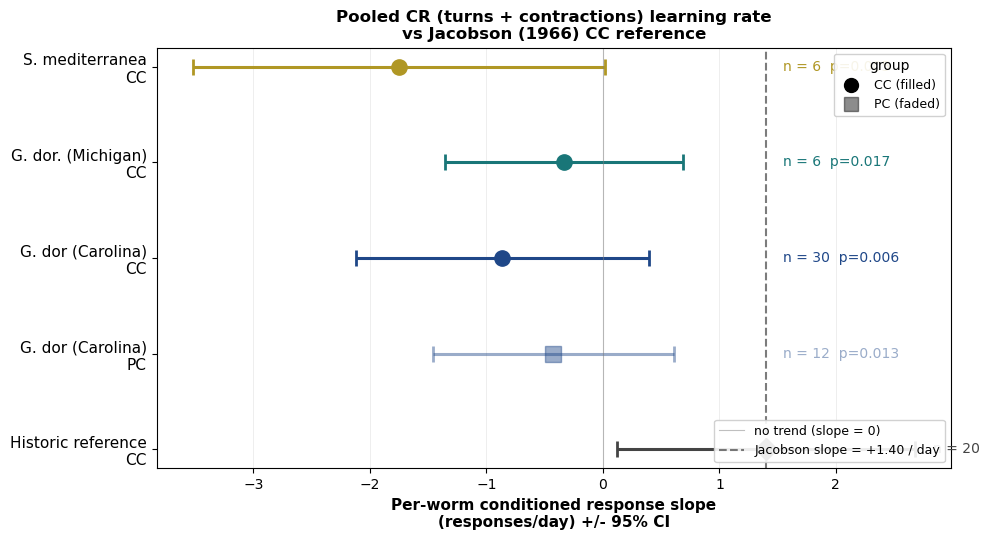


══════════════════════════════════════════════════════════════════════════════
  POOLED FOREST PLOT SUMMARY (values shown in plot)
══════════════════════════════════════════════════════════════════════════════
  Population                             n   Mean slope                  95% CI   Welch p
  ──────────────────────────────────────────────────────────────────────────────
  S. mediterranea CC                     6       -1.750  [-3.521, +0.021]    0.0048
  G. dor. (Michigan) CC                  6       -0.333  [-1.357, +0.690]    0.0168
  G. dor (Carolina) CC                  30       -0.863  [-2.120, +0.394]    0.0056
  G. dor (Carolina) PC                  12       -0.425  [-1.461, +0.611]    0.0131
  Historic reference CC                 20       +1.400  [+0.121, +2.679]       ref
══════════════════════════════════════════════════════════════════════════════


In [10]:
# ==============================================================================
# BLOCK 4c: POOLED (TURN + CONTRACTION) SLOPE vs JACOBSON
# ==============================================================================
# For each worm, sum CRturn + CRcon per day to get a total CR count, then
# compute per-worm OLS slope on that pooled daily total.  Compare the resulting
# slope distribution to Jacobson's CC reference using Welch's t-test.
# ==============================================================================

def per_worm_slopes_pooled(df, troupes, days):
    """Per-worm OLS slope of daily-summed (CRturn + CRcon) vs Day.

    Only includes a worm if at least one of CRturn/CRcon has non-NaN
    data, so populations with no scored data are correctly returned as
    empty (matching the per-behaviour function).
    """
    slopes = []
    sub = df[df['Troupe'].isin(troupes) & df['Day'].isin(days)].copy()
    if sub.empty:
        return np.array(slopes)
    for w in range(1, 7):
        turn_col = f"CRturn_W{w}"
        con_col  = f"CRcon_W{w}"
        has_turn = turn_col in sub.columns
        has_con  = con_col in sub.columns
        if not has_turn and not has_con:
            continue

        turn_raw = pd.to_numeric(sub[turn_col], errors='coerce') if has_turn else pd.Series(np.nan, index=sub.index)
        con_raw  = pd.to_numeric(sub[con_col],  errors='coerce') if has_con  else pd.Series(np.nan, index=sub.index)

        either_valid = turn_raw.notna() | con_raw.notna()
        if not either_valid.any():
            continue

        pooled = turn_raw.fillna(0).values + con_raw.fillna(0).values
        pooled[~either_valid.values] = np.nan

        tmp = pd.DataFrame({'Troupe': sub['Troupe'].values,
                            'Day':    sub['Day'].values,
                            'val':    pooled})
        daily = (tmp.dropna(subset=['val'])
                    .groupby(['Troupe', 'Day'], as_index=False)['val']
                    .sum())
        for troupe, g in daily.groupby('Troupe'):
            if g['Day'].nunique() < 2:
                continue
            reg = stats.linregress(g['Day'].astype(float).values,
                                   g['val'].astype(float).values)
            if np.isfinite(reg.slope):
                slopes.append(reg.slope)
    return np.array(slopes)


print("\n" + "═" * 78)
print("  POOLED (CRturn + CRcon) SLOPE vs JACOBSON")
print("═" * 78)

pooled_results = {}
for scorer in SCORERS:
    if scorer not in dfs:
        continue
    df_scorer = dfs[scorer]
    species   = SCORER_CONFIG[scorer]['label_name']
    for group_name, troupes in [('CC', TC_TROUPES), ('PC', TP_TROUPES)]:
        slopes = per_worm_slopes_pooled(df_scorer, troupes, DAYS)
        name = f"{species} · {group_name} · pooled"
        pooled_results[name] = compare_to_jacobson(name, slopes)


# ── Forest plot: pooled slopes vs Jacobson ───────────────────────────────────
pooled_entries = []
for scorer in SCORERS:
    if scorer not in dfs:
        continue
    species = SCORER_CONFIG[scorer]['label_name']
    colour  = species_colour[scorer]
    for group_name in ['CC', 'PC']:
        res = pooled_results.get(f"{species} · {group_name} · pooled")
        if res is None:
            continue
        pooled_entries.append(dict(
            label  = f"{species}\n{group_name}",
            n      = res['n'],
            mu     = res['mu'],
            lo     = res['ci'][0],
            hi     = res['ci'][1],
            p      = res['p2_two'],
            colour = colour,
            marker = 'o' if group_name == 'CC' else 's',
            alpha  = 1.0 if group_name == 'CC' else 0.45,
        ))

jac_tc = stats.t.ppf(0.975, df=JAC_DF)
pooled_entries.append(dict(
    label  = 'Historic reference\nCC',
    n      = 20,
    mu     = JAC_SLOPE,
    lo     = JAC_SLOPE - jac_tc * JAC_SLOPE_SE,
    hi     = JAC_SLOPE + jac_tc * JAC_SLOPE_SE,
    p      = np.nan,
    colour = '#444444',
    marker = 'D',
    alpha  = 1.0,
))

fig, ax = plt.subplots(figsize=(10, 5.5))
ypos = list(range(len(pooled_entries), 0, -1))
for y, e in zip(ypos, pooled_entries):
    ax.errorbar(
        e['mu'], y,
        xerr=[[e['mu'] - e['lo']], [e['hi'] - e['mu']]],
        fmt=e['marker'], color=e['colour'], alpha=e['alpha'],
        markersize=11, markeredgecolor=e['colour'], markerfacecolor=e['colour'],
        capsize=6, capthick=2, linewidth=2.2,
    )
    p_txt = '' if not np.isfinite(e['p']) else f"  p={e['p']:.3f}"
    ax.text(
        max(e['hi'], JAC_SLOPE) + 0.15, y,
        f"n = {e['n']}{p_txt}",
        va='center', ha='left', fontsize=10, color=e['colour'], alpha=e['alpha'],
    )

ax.axvline(0, color='gray', linestyle='-',  linewidth=0.8, alpha=0.5,
           label='no trend (slope = 0)')
ax.axvline(JAC_SLOPE, color='#444444', linestyle='--', linewidth=1.5, alpha=0.7,
           label=f'Jacobson slope = {JAC_SLOPE:+.2f} / day')

ax.set_yticks(ypos)
ax.set_yticklabels([e['label'] for e in pooled_entries], fontsize=11)
ax.set_xlabel('Per-worm conditioned response slope\n(responses/day) +/- 95% CI',
              fontsize=11, fontweight='bold')
ax.set_title('Pooled CR (turns + contractions) learning rate\nvs Jacobson (1966) CC reference',
             fontsize=12, fontweight='bold')

legend_handles = [
    mlines.Line2D([], [], marker='o', color='black', linestyle='None',
                  markersize=10, alpha=1.0,  label='CC (filled)'),
    mlines.Line2D([], [], marker='s', color='black', linestyle='None',
                  markersize=10, alpha=0.45, label='PC (faded)'),
]
leg1 = ax.legend(handles=legend_handles, loc='upper right', fontsize=9,
                 framealpha=0.9, title='group')
ax.add_artist(leg1)
ax.legend(loc='lower right', fontsize=9, framealpha=0.9)

ax.grid(True, axis='x', linestyle='-', linewidth=0.5, alpha=0.3)
ax.set_axisbelow(True)
plt.tight_layout()

savepath_pooled = os.path.join(SAVE_PATH, 'Fig_S1B_SlopeVsJacobson_Pooled.svg')
fig.savefig(savepath_pooled, dpi=300, bbox_inches='tight')
print(f"\n▶ Pooled forest plot saved to: {savepath_pooled}")
plt.show()

# ── Cross-check: print summary table matching forest plot entries ────────────
print("\n" + "═" * 78)
print("  POOLED FOREST PLOT SUMMARY (values shown in plot)")
print("═" * 78)
print(f"  {'Population':<35} {'n':>4}  {'Mean slope':>11}  {'95% CI':>22}  {'Welch p':>8}")
print("  " + "─" * 78)
for e in pooled_entries:
    lbl = e['label'].replace('\n', ' ')
    if np.isfinite(e['p']):
        print(f"  {lbl:<35} {e['n']:>4}  {e['mu']:>+11.3f}  [{e['lo']:>+.3f}, {e['hi']:>+.3f}]  {e['p']:>8.4f}")
    else:
        print(f"  {lbl:<35} {e['n']:>4}  {e['mu']:>+11.3f}  [{e['lo']:>+.3f}, {e['hi']:>+.3f}]  {'ref':>8}")
print("═" * 78)